In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
# Download the balanced RAF-DB dataset
print("Downloading RAF-DB dataset...")
dataset_path = kagglehub.dataset_download('dollyprajapati182/balanced-raf-db-dataset-7575-grayscale')
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'balanced-raf-db-dataset-7575-grayscale' dataset.
Dataset downloaded to: /kaggle/input/balanced-raf-db-dataset-7575-grayscale


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from tensorflow.keras.utils import to_categorical

# Scikit-learn import
from sklearn.preprocessing import LabelEncoder

# Matplotlib setup
%matplotlib inline

In [3]:
# --- IMPORTANT: New Image Size ---
IMG_SIZE = 100

# This is the path from the cell above
DATASET_DIR = dataset_path

# --- CORRECTED PATHS ---
# The 'train' and 'test' folders are directly inside the DATASET_DIR
TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
TEST_DIR = os.path.join(DATASET_DIR, 'test')

print(f"Image Size (Height & Width): {IMG_SIZE}px")
print(f"Training Directory: {TRAIN_DIR}")
print(f"Testing Directory: {TEST_DIR}")

Image Size (Height & Width): 100px
Training Directory: /kaggle/input/balanced-raf-db-dataset-7575-grayscale/train
Testing Directory: /kaggle/input/balanced-raf-db-dataset-7575-grayscale/test


In [4]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        label_dir = os.path.join(dir, label)
        # Check if it's a directory
        if os.path.isdir(label_dir):
            for imagename in os.listdir(label_dir):
                image_paths.append(os.path.join(label_dir, imagename))
                labels.append(label)
            print(label, "completed")
    return image_paths, labels

In [5]:
print("Creating Training DataFrame...")
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

print("\nCreating Testing DataFrame...")
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

print("\n--- DataFrames Created ---")
print(train.head())

Creating Training DataFrame...
surprise completed
fear completed
angry completed
neutral completed
sad completed
disgust completed
happy completed

Creating Testing DataFrame...
surprise completed
fear completed
angry completed
neutral completed
sad completed
disgust completed
happy completed

--- DataFrames Created ---
                                               image     label
0  /kaggle/input/balanced-raf-db-dataset-7575-gra...  surprise
1  /kaggle/input/balanced-raf-db-dataset-7575-gra...  surprise
2  /kaggle/input/balanced-raf-db-dataset-7575-gra...  surprise
3  /kaggle/input/balanced-raf-db-dataset-7575-gra...  surprise
4  /kaggle/input/balanced-raf-db-dataset-7575-gra...  surprise


In [6]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        # Load image, ensure color_mode is grayscale and target_size is set
        img = load_img(image, color_mode='grayscale', target_size=(IMG_SIZE, IMG_SIZE))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    # Reshape for the model: (num_images, height, width, channels)
    features = features.reshape(len(features), IMG_SIZE, IMG_SIZE, 1)
    return features

In [7]:
print("Extracting training features...")
train_features = extract_features(train['image'])

print("\nExtracting testing features...")
test_features = extract_features(test['image'])

print("Feature extraction complete.")

Extracting training features...


  0%|          | 0/30023 [00:00<?, ?it/s]


Extracting testing features...


  0%|          | 0/4165 [00:00<?, ?it/s]

Feature extraction complete.


In [8]:
x_train = train_features / 255.0
x_test = test_features / 255.0

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (30023, 100, 100, 1)
x_test shape: (4165, 100, 100, 1)


In [9]:
le = LabelEncoder()
le.fit(train['label'])

y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

# Get the number of classes
num_classes = len(le.classes_)
print(f"Found {num_classes} classes: {le.classes_}")

Found 7 classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


In [10]:
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (30023, 7)
y_test shape: (4165, 7)


In [11]:
model = Sequential([
    # --- Input shape is now 100x100 ---
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    Conv2D(128, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    Conv2D(256, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    Conv2D(512, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    Conv2D(512, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),

    # --- Final layer automatically uses the number of classes ---
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,164,359 (31.14 MB)

 Trainable params: 8,164,359 (31.14 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
print("Starting model training...")

# You can start with 50 epochs and add more if needed
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=50,
                    validation_data=(x_test, y_test))

print("Model training complete.")

Starting model training...
Epoch 1/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 88s 149ms/step - accuracy: 0.3300 - loss: 1.6746 - val_accuracy: 0.5467 - val_loss: 1.2342
Epoch 2/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.5265 - loss: 1.2665 - val_accuracy: 0.6355 - val_loss: 1.0194
Epoch 3/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.5896 - loss: 1.1053 - val_accuracy: 0.6747 - val_loss: 0.9014
Epoch 4/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.6371 - loss: 0.9909 - val_accuracy: 0.7212 - val_loss: 0.7872
Epoch 5/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.6625 - loss: 0.9085 - val_accuracy: 0.7628 - val_loss: 0.7102
Epoch 6/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.6896 - loss: 0.8511 - val_accuracy: 0.7697 - val_loss: 0.6519
Epoch 7/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.7072 - loss: 0.7969 - val_accuracy: 0.7899 - val_loss: 0.6337
Epoch 8/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step -

In [14]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/projectCodes/image_model.h5')

Mounted at /content/drive


In [15]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8936 - loss: 0.3246
Test Loss: 0.3246
Test Accuracy: 89.36%


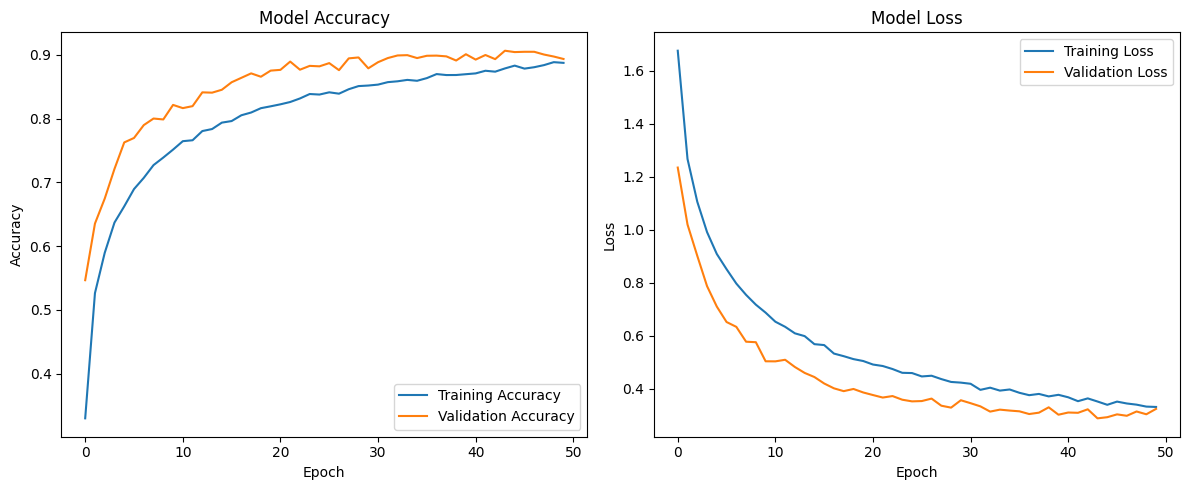

In [16]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step


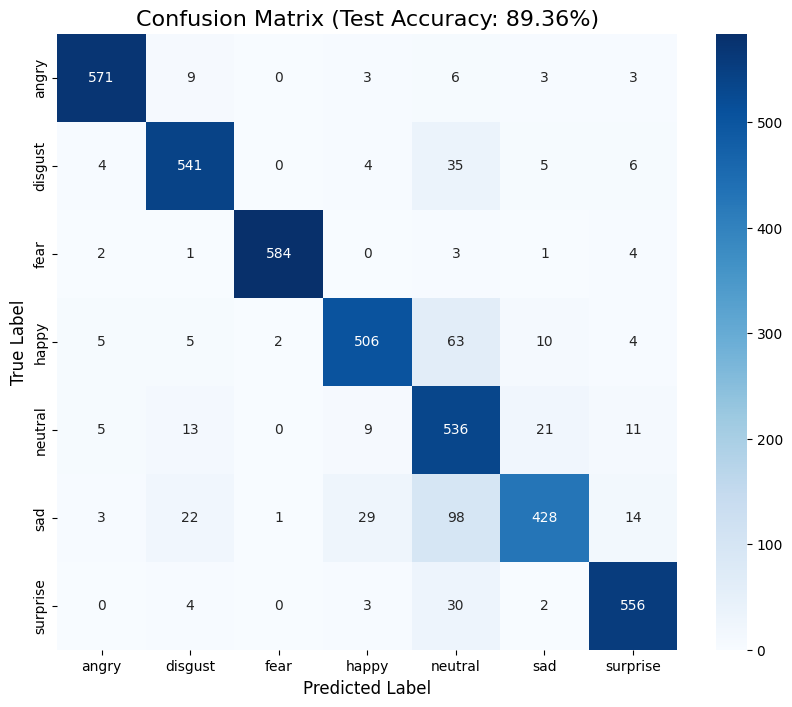

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns # We only need to import seaborn

# 1. Get model predictions (as probabilities) for the entire test set
y_pred_probs = model.predict(x_test)

# 2. Convert probabilities to single class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# 3. Convert the one-hot true labels to single class labels
y_true_labels = np.argmax(y_test, axis=1)

# 4. Get the human-readable class names from your LabelEncoder
try:
    label_names = list(le.classes_)
except NameError:
    print("Warning: 'le' (LabelEncoder) not found. Using numbers for labels.")
    label_names = [str(i) for i in range(num_classes)]

# 5. Generate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# 6. Plot the heatmap
plt.figure(figsize=(10, 8)) # Set the size of the figure
sns.heatmap(cm,
            annot=True,     # Show the numbers in each cell
            fmt='d',        # Format the numbers as integers
            cmap='Blues',   # Use a blue color scheme
            xticklabels=label_names,
            yticklabels=label_names)

plt.title(f'Confusion Matrix (Test Accuracy: {accuracy * 100:.2f}%)', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [18]:
from sklearn.metrics import classification_report

# Use the variables we already created for the confusion matrix
print("\n--- Classification Report ---")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_names))


--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.97      0.96      0.96       595
     disgust       0.91      0.91      0.91       595
        fear       0.99      0.98      0.99       595
       happy       0.91      0.85      0.88       595
     neutral       0.70      0.90      0.78       595
         sad       0.91      0.72      0.80       595
    surprise       0.93      0.93      0.93       595

    accuracy                           0.89      4165
   macro avg       0.90      0.89      0.89      4165
weighted avg       0.90      0.89      0.89      4165



In [ ]:
# model.save("raf_db_model.keras")

# print("Model saved as raf_db_model.keras")

Model saved as raf_db_model.keras


In [19]:
from google.colab import drive
import os

# 1. Mount your Google Drive
# A pop-up window will ask for your permission.
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define the source and destination paths
source_file = 'image_model.h5'
destination_path = f'/content/drive/MyDrive/projectCodes/image_model.h5'

# 3. Copy the file
print(f"Copying '{source_file}' to your Google Drive...")
try:
    # Use !cp to copy the file
    !cp {source_file} {destination_path}
    print("\n✅ Success!")
    print(f"Model permanently saved to your Google Drive as: {destination_path}")

except FileNotFoundError:
    print("\n❌ Error: Could not find '{source_file}'.")
    print("Please make sure you ran the `model.save()` cell just before this one.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying 'image_model.h5' to your Google Drive...
cp: cannot stat 'image_model.h5': No such file or directory

✅ Success!
Model permanently saved to your Google Drive as: /content/drive/MyDrive/projectCodes/image_model.h5


In [ ]:
# Create the list of label names from the encoder
label_map = list(le.classes_)
print(f"Label map: {label_map}")

# Helper function to process a single image (updated for 100x100)
def ef(image_path):
    img = load_img(image_path, color_mode='grayscale', target_size=(IMG_SIZE, IMG_SIZE))
    feature = np.array(img)
    # Reshape to (1, 100, 100, 1)
    feature = feature.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    return feature / 255.0

Label map: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [27]:
# Let's test a 'happiness' image from the test set
image_path = os.path.join(destination_path, 'happiness', 'test_0005.jpg')
actual_label = 'happiness'

print(f"Original image is of: {actual_label}")

try:
    # Process the image
    img = ef(image_path)

    # Make a prediction
    pred = model.predict(img)
    pred_label = label_map[pred.argmax()]
    print(f"Model prediction is: {pred_label}")

    # Display the image (reshaped to 100x100)
    plt.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Actual: {actual_label} | Predicted: {pred_label}")
    plt.show()

except FileNotFoundError:
    print(f"Error: Image not found at the path: {image_path}")

Original image is of: happiness


NameError: name 'ef' is not defined

Testing one image for each label: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


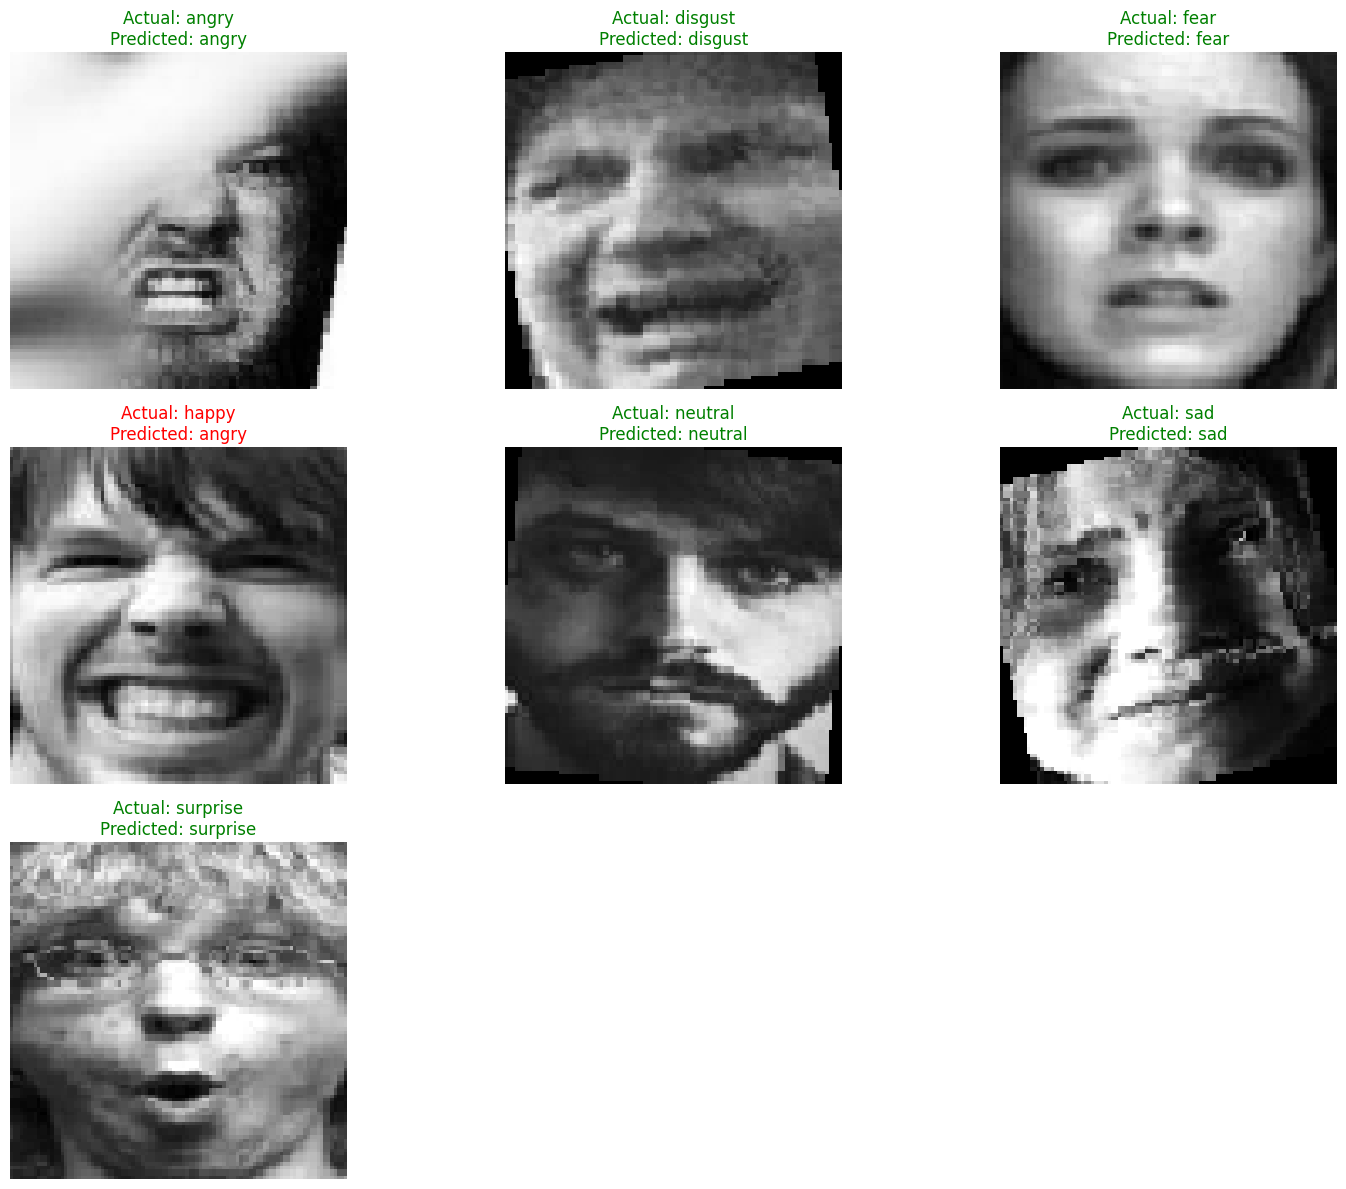

In [ ]:
import os
import matplotlib.pyplot as plt

# This label_map variable was created in your cell #17
print(f"Testing one image for each label: {label_map}")

# Create a figure to plot all 7 emotions
# We'll use a 3x3 grid (which has 9 spots) for our 7 images
plt.figure(figsize=(15, 12))

# Loop through each label and plot one example
for i, label in enumerate(label_map):

    # 1. Find an example image path
    label_dir = os.path.join(TEST_DIR, label)

    # Find the first image in that directory
    try:
        first_image_name = os.listdir(label_dir)[0]
        image_path = os.path.join(label_dir, first_image_name)
    except (FileNotFoundError, IndexError):
        print(f"Could not find images for label: {label}")
        continue

    actual_label = label

    # 2. Process the image and predict
    # The 'ef' function was defined in your cell #17
    img = ef(image_path)

    # We add this to silence the '1/1' prediction output for each loop
    pred = model.predict(img, verbose=0)
    pred_label = label_map[pred.argmax()]

    # 3. Create a subplot in our 3x3 grid
    plt.subplot(3, 3, i + 1)
    plt.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')

    # 4. Set the title with the result (Green for correct, Red for incorrect)
    title_color = 'green' if actual_label == pred_label else 'red'
    plt.title(f"Actual: {actual_label}\nPredicted: {pred_label}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Download the OpenCV Haar Cascade for face detection
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml

--2026-04-11 16:40:02--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.03s   

2026-04-11 16:40:02 (30.8 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]



In [23]:
import cv2
from google.colab import output
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from base64 import b64decode
import numpy as np

# Function to take a photo from the webcam
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture button to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = output.eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [25]:
# 1. Load the pre-trained face detector
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# 2. Load your model (if not already loaded)
# from tensorflow.keras.models import load_model
# model = load_model("raf_db_model.keras")

# 3. Load the label map and image size (from your previous cells)
# label_map = ['anger', 'disgust', 'fear', 'happiness', 'neutrality', 'sadness', 'surprise']
# IMG_SIZE = 100

print("Click 'Capture' in the output below. You may need to grant camera permissions.")

try:
    # 4. Take the photo
    filename = take_photo()

    # 5. Load the captured image
    frame = cv2.imread(filename)
    # Create a grayscale version for the face detector
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 6. Detect faces in the image
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        print("No faces detected.")
    else:
        print(f"Detected {len(faces)} face(s).")

    # 7. Loop over each detected face
    for (x, y, w, h) in faces:
        # 8. Crop the face (Region of Interest)
        roi_gray = gray[y:y+h, x:x+w]

        # 9. Preprocess the face for YOUR model
        # (Resize, reshape, normalize)
        final_face = cv2.resize(roi_gray, (IMG_SIZE, IMG_SIZE))
        final_face = final_face.reshape(1, IMG_SIZE, IMG_SIZE, 1)
        final_face = final_face / 255.0

        # 10. Make a prediction
        pred = model.predict(final_face, verbose=0)
        pred_label = label_map[pred.argmax()]

        # 11. Draw the rectangle and label on the *original color* image
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, pred_label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # 12. Display the final image
    cv2_imshow(frame)

except Exception as err:
    print(f"An error occurred: {err}")
    print("Please make sure your browser has camera permissions enabled.")

Click 'Capture' in the output below. You may need to grant camera permissions.


<IPython.core.display.Javascript object>

Detected 1 face(s).
An error occurred: name 'label_map' is not defined
Please make sure your browser has camera permissions enabled.


In [26]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Load face detector
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# 2. Define class labels (same as training)
classes = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Angry", "Neutral"]

print("Click 'Capture' below and allow camera access.")

try:
    # 3. Capture image
    filename = take_photo()

    # 4. Read image
    frame = cv2.imread(filename)

    # Convert to grayscale for detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 5. Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        print("No faces detected.")
    else:
        print(f"Detected {len(faces)} face(s).")

    # 6. Process each face
    for (x, y, w, h) in faces:
        # Crop face
        roi_gray = gray[y:y+h, x:x+w]

        # 🔥 IMPORTANT: match training preprocessing
        face = cv2.resize(roi_gray, (48, 48))
        face = face / 255.0
        face = face.reshape(1, 48, 48, 1)

        # 7. Prediction
        pred = model.predict(face, verbose=0)
        class_index = np.argmax(pred)
        pred_label = classes[class_index]

        # 8. Draw results
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(
            frame,
            pred_label,
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 255, 0),
            2
        )

    # 9. Show output
    cv2_imshow(frame)

except Exception as err:
    print(f"An error occurred: {err}")
    print("Make sure camera permissions are enabled.")

Click 'Capture' below and allow camera access.


<IPython.core.display.Javascript object>

Detected 1 face(s).
An error occurred: Graph execution error:

Detected at node sequential_1/dense_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [1,512], In[1]: [8192,512]

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
File "/usr/local/lib/python3.12/d